# 06 XGBoost tuning + modelo final + análisis de errores

**Iteración:** 4 modelo final de la R4

## Objetivos

1. **Tuning de hiperparámetros**: explorar 5 combinaciones de `n_estimators`, `max_depth`, `learning_rate` y `subsample` para encontrar la configuración óptima.
2. **Modelo final**: re-entrenar con la mejor configuración usando `train + validation` combinados.
3. **Evaluación en test**: medir el rendimiento real sobre el conjunto de test, que no se ha utilizado en ninguna iteración previa.
4. **Análisis de errores**: identificar tiendas y situaciones donde el modelo falla más, documentando casos problemáticos para futuras mejoras.
5. **Model Artifact**: serializar el modelo final con `joblib` y subirlo a S3 como artefacto reutilizable para la actividad R5.

## Justificación del enfoque

Se opta por una **búsqueda manual estructurada**, haremos 5 configuraciones bien elegidas, en lugar de un `GridSearchCV` exhaustivo:

- Con 591.036 filas y validación cruzada k-fold, un grid completo tardaría horas y agotaría los créditos del Learner Lab.
- Las 5 combinaciones cubren las dimensiones clave del espacio: capacidad del modelo (`max_depth`), velocidad de aprendizaje (`learning_rate`), número de árboles (`n_estimators`) y regularización por submuestreo (`subsample`).
- Cada configuración se evalúa contra el mismo split de validation usado en iteraciones anteriores, garantizando comparabilidad.

In [1]:
!pip install seaborn
!conda install -y -c conda-forge xgboost

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.3.2

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.



In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import boto3
from io import BytesIO
import time
import os
import joblib

import xgboost as xgb

# Configuración
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
sns.set_style("whitegrid")
pd.set_option('display.max_columns', 100)

print(f"Imports cargados | XGBoost {xgb.__version__}")

# Carga de datos desde S3
BUCKET_NAME = "prediccion-demanda-processed-319501512128"
PREFIX_SPLITS = "rossmann/splits/"
TIMESTAMP = "20260410_054619"

s3_client = boto3.client("s3")

def load_csv_from_s3(bucket, key):
    response = s3_client.get_object(Bucket=bucket, Key=key)
    return pd.read_csv(BytesIO(response["Body"].read()))

print("\nCargando splits...")
df_train = load_csv_from_s3(BUCKET_NAME, f"{PREFIX_SPLITS}train_{TIMESTAMP}.csv")
df_val = load_csv_from_s3(BUCKET_NAME, f"{PREFIX_SPLITS}validation_{TIMESTAMP}.csv")
df_test = load_csv_from_s3(BUCKET_NAME, f"{PREFIX_SPLITS}test_{TIMESTAMP}.csv")

for df in [df_train, df_val, df_test]:
    df["Date"] = pd.to_datetime(df["Date"])

print(f"Train: {df_train.shape}")
print(f"Val:   {df_val.shape}")
print(f"Test:  {df_test.shape}")

Imports cargados | XGBoost 3.2.0

Cargando splits...
Train: (591036, 20)
Val:   (126651, 20)
Test:  (126651, 20)


In [3]:
# Métricas
def rmspe(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred)) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(np.array(y_true) - np.array(y_pred)))

def evaluate(y_true, y_pred, label=""):
    metrics = {"RMSPE": rmspe(y_true, y_pred), "RMSE": rmse(y_true, y_pred), "MAE": mae(y_true, y_pred)}
    if label:
        print(f"{label}")
    print(f"   RMSPE: {metrics['RMSPE']:.4f}  ({metrics['RMSPE']*100:.2f}%)")
    print(f"   RMSE:  {metrics['RMSE']:.2f} €")
    print(f"   MAE:   {metrics['MAE']:.2f} €")
    return metrics

# Feature engineering
print("Calculando estadísticas para feature engineering...")

store_stats = df_train.groupby("Store")["Sales"].agg([
    ("Store_Sales_mean", "mean"),
    ("Store_Sales_median", "median"),
    ("Store_Sales_std", "std"),
    ("Store_Sales_min", "min"),
    ("Store_Sales_max", "max"),
    ("Store_Sales_p25", lambda x: x.quantile(0.25)),
    ("Store_Sales_p75", lambda x: x.quantile(0.75)),
]).reset_index()

store_dow_stats = df_train.groupby(["Store", "DayOfWeek"])["Sales"].agg([
    ("StoreDOW_Sales_mean", "mean"),
    ("StoreDOW_Sales_median", "median"),
]).reset_index()

def enrich_features(df, store_stats, store_dow_stats):
    df = df.copy()
    df = df.merge(store_stats, on="Store", how="left")
    df = df.merge(store_dow_stats, on=["Store", "DayOfWeek"], how="left")
    df["DayOfMonth"] = df["Date"].dt.day
    df["IsBeginningOfMonth"] = (df["DayOfMonth"] <= 10).astype(int)
    df["IsEndOfMonth"] = (df["DayOfMonth"] >= 20).astype(int)
    df["IsWeekend"] = df["DayOfWeek"].isin([6, 7]).astype(int)
    return df

df_train_fe = enrich_features(df_train, store_stats, store_dow_stats)
df_val_fe = enrich_features(df_val, store_stats, store_dow_stats)
df_test_fe = enrich_features(df_test, store_stats, store_dow_stats)

TARGET = "Sales"
EXCLUDE = ["Sales", "Customers", "Date"]
FEATURES = [c for c in df_train_fe.columns if c not in EXCLUDE]

X_train = df_train_fe[FEATURES].values
y_train = df_train_fe[TARGET].values
X_val = df_val_fe[FEATURES].values
y_val = df_val_fe[TARGET].values
X_test = df_test_fe[FEATURES].values
y_test = df_test_fe[TARGET].values

print(f"Features preparadas: {len(FEATURES)} columnas")
print(f"   X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")

Calculando estadísticas para feature engineering...
Features preparadas: 30 columnas
   X_train: (591036, 30) | X_val: (126651, 30) | X_test: (126651, 30)


In [4]:
# Búsqueda manual estructurada de hiperparámetros
configs = [
    {"name": "Config 1 (referencia NB05)", "n_estimators": 200, "max_depth": 6,  "learning_rate": 0.1,  "subsample": 1.0},
    {"name": "Config 2 (más profundo)",     "n_estimators": 200, "max_depth": 10, "learning_rate": 0.1,  "subsample": 1.0},
    {"name": "Config 3 (lr bajo + más árboles)", "n_estimators": 400, "max_depth": 8,  "learning_rate": 0.05, "subsample": 1.0},
    {"name": "Config 4 (regularización por subsample)", "n_estimators": 400, "max_depth": 8,  "learning_rate": 0.05, "subsample": 0.8},
    {"name": "Config 5 (config agresiva)",  "n_estimators": 600, "max_depth": 10, "learning_rate": 0.03, "subsample": 0.8},
]

results_tuning = []

for cfg in configs:
    print(f"\n{'='*60}")
    print(f"Entrenando: {cfg['name']}")
    print(f"  n_estimators={cfg['n_estimators']}, max_depth={cfg['max_depth']}, "
          f"learning_rate={cfg['learning_rate']}, subsample={cfg['subsample']}")
    
    t0 = time.time()
    model = xgb.XGBRegressor(
        n_estimators=cfg["n_estimators"],
        max_depth=cfg["max_depth"],
        learning_rate=cfg["learning_rate"],
        subsample=cfg["subsample"],
        objective="reg:squarederror",
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    train_time = time.time() - t0
    
    y_pred = np.clip(model.predict(X_val), 0, None)
    metrics = {
        "RMSPE": rmspe(y_val, y_pred),
        "RMSE": rmse(y_val, y_pred),
        "MAE": mae(y_val, y_pred),
        "TrainTime_s": train_time,
    }
    
    results_tuning.append({**cfg, **metrics})
    print(f"  RMSPE: {metrics['RMSPE']*100:.2f}% | RMSE: {metrics['RMSE']:.0f} € | "
          f"Tiempo: {train_time:.1f}s")

# Resumen
df_tuning = pd.DataFrame(results_tuning)
df_tuning_sorted = df_tuning.sort_values("RMSPE")
print("\n" + "="*60)
print("RESUMEN DE TUNING (ordenado por RMSPE)")
print("="*60)
print(df_tuning_sorted[["name", "n_estimators", "max_depth", "learning_rate", 
                        "subsample", "RMSPE", "RMSE", "TrainTime_s"]].to_string(index=False))

best_config = df_tuning_sorted.iloc[0]
print(f"\nMejor configuración: {best_config['name']}")
print(f"   RMSPE: {best_config['RMSPE']*100:.2f}%")


Entrenando: Config 1 (referencia NB05)
  n_estimators=200, max_depth=6, learning_rate=0.1, subsample=1.0
  RMSPE: 33.62% | RMSE: 1097 € | Tiempo: 14.5s

Entrenando: Config 2 (más profundo)
  n_estimators=200, max_depth=10, learning_rate=0.1, subsample=1.0
  RMSPE: 34.71% | RMSE: 1194 € | Tiempo: 29.1s

Entrenando: Config 3 (lr bajo + más árboles)
  n_estimators=400, max_depth=8, learning_rate=0.05, subsample=1.0
  RMSPE: 34.19% | RMSE: 1212 € | Tiempo: 34.6s

Entrenando: Config 4 (regularización por subsample)
  n_estimators=400, max_depth=8, learning_rate=0.05, subsample=0.8
  RMSPE: 34.27% | RMSE: 1186 € | Tiempo: 37.0s

Entrenando: Config 5 (config agresiva)
  n_estimators=600, max_depth=10, learning_rate=0.03, subsample=0.8
  RMSPE: 34.35% | RMSE: 1184 € | Tiempo: 75.2s

RESUMEN DE TUNING (ordenado por RMSPE)
                                   name  n_estimators  max_depth  learning_rate  subsample    RMSPE        RMSE  TrainTime_s
             Config 1 (referencia NB05)          

In [5]:
# Modelo final, re-entrenamos con train + val combinados
print("Entrenando modelo final con train + validation combinados...")

X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

print(f"   X_trainval: {X_trainval.shape}")

t0 = time.time()
model_final = xgb.XGBRegressor(
    n_estimators=int(best_config["n_estimators"]),
    max_depth=int(best_config["max_depth"]),
    learning_rate=float(best_config["learning_rate"]),
    subsample=float(best_config["subsample"]),
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)
model_final.fit(X_trainval, y_trainval, verbose=False)
print(f"Modelo final entrenado en {time.time()-t0:.1f}s")

# Evaluación en test
y_pred_test = np.clip(model_final.predict(X_test), 0, None)
print("\n" + "="*60)
metrics_final_test = evaluate(y_test, y_pred_test, label="MODELO FINAL — Test")
print("="*60)

# Comparación final
print("\nEVOLUCIÓN COMPLETA POR ITERACIÓN:")
print(f"   Iter 0 — Baseline ingenuo (val):     38.03%")
print(f"   Iter 1 — Ridge (val):                59.08%")
print(f"   Iter 2 — XGBoost base (val):         37.16%")
print(f"   Iter 3 — XGBoost + FE (val):         33.62%")
print(f"   Iter 4 — XGBoost tuneado (val):      {best_config['RMSPE']*100:.2f}%")
print(f"   Iter 4 — Modelo final (TEST):        {metrics_final_test['RMSPE']*100:.2f}%")

improvement_total = (0.3803 - metrics_final_test['RMSPE']) / 0.3803 * 100
print(f"\n   Mejora total vs baseline: {improvement_total:+.1f}%")

Entrenando modelo final con train + validation combinados...
   X_trainval: (717687, 30)
Modelo final entrenado en 17.2s

MODELO FINAL — Test
   RMSPE: 0.1483  (14.83%)
   RMSE:  1050.84 €
   MAE:   740.67 €

EVOLUCIÓN COMPLETA POR ITERACIÓN:
   Iter 0 — Baseline ingenuo (val):     38.03%
   Iter 1 — Ridge (val):                59.08%
   Iter 2 — XGBoost base (val):         37.16%
   Iter 3 — XGBoost + FE (val):         33.62%
   Iter 4 — XGBoost tuneado (val):      33.62%
   Iter 4 — Modelo final (TEST):        14.83%

   Mejora total vs baseline: +61.0%


In [6]:
# Análisis de errores en test
df_errors = df_test_fe.copy()
df_errors["Predicted"] = y_pred_test
df_errors["Error"] = df_errors["Sales"] - df_errors["Predicted"]
df_errors["AbsError"] = df_errors["Error"].abs()
df_errors["PctError"] = (df_errors["Error"] / df_errors["Sales"]) * 100

print("="*60)
print("ANÁLISIS DE ERRORES EN TEST")
print("="*60)

# Distribución del error
print(f"\nDistribución de errores absolutos (€):")
print(f"   Media:     {df_errors['AbsError'].mean():.0f}")
print(f"   Mediana:   {df_errors['AbsError'].median():.0f}")
print(f"   P75:       {df_errors['AbsError'].quantile(0.75):.0f}")
print(f"   P95:       {df_errors['AbsError'].quantile(0.95):.0f}")
print(f"   Máximo:    {df_errors['AbsError'].max():.0f}")

# Tiendas con peor RMSPE
print("\nTop 10 tiendas con peor predicción (RMSPE):")
store_errors = df_errors.groupby("Store").apply(
    lambda g: rmspe(g["Sales"], g["Predicted"]),
    include_groups=False
).reset_index(name="RMSPE_store")
worst_stores = store_errors.sort_values("RMSPE_store", ascending=False).head(10)
print(worst_stores.to_string(index=False))

# Errores por contexto (festivos, promos)
print("\nRMSPE por contexto:")
print(f"   Días sin promoción:        {rmspe(df_errors[df_errors['Promo']==0]['Sales'], df_errors[df_errors['Promo']==0]['Predicted'])*100:.2f}%")
print(f"   Días con promoción:        {rmspe(df_errors[df_errors['Promo']==1]['Sales'], df_errors[df_errors['Promo']==1]['Predicted'])*100:.2f}%")
print(f"   Días sin festivo escolar:  {rmspe(df_errors[df_errors['SchoolHoliday']==0]['Sales'], df_errors[df_errors['SchoolHoliday']==0]['Predicted'])*100:.2f}%")
print(f"   Días con festivo escolar:  {rmspe(df_errors[df_errors['SchoolHoliday']==1]['Sales'], df_errors[df_errors['SchoolHoliday']==1]['Predicted'])*100:.2f}%")

# RMSPE por día de la semana
print("\nRMSPE por día de la semana:")
dow_map = {1: "Lun", 2: "Mar", 3: "Mié", 4: "Jue", 5: "Vie", 6: "Sáb", 7: "Dom"}
for dow in sorted(df_errors["DayOfWeek"].unique()):
    sub = df_errors[df_errors["DayOfWeek"] == dow]
    print(f"   {dow_map[dow]} (n={len(sub):>5}): RMSPE = {rmspe(sub['Sales'], sub['Predicted'])*100:.2f}%")

ANÁLISIS DE ERRORES EN TEST

Distribución de errores absolutos (€):
   Media:     741
   Mediana:   545
   P75:       989
   P95:       2092
   Máximo:    32301

Top 10 tiendas con peor predicción (RMSPE):
 Store  RMSPE_store
   415     0.500417
   292     0.494497
   815     0.474922
   770     0.423927
   183     0.422425
   839     0.404112
   113     0.392152
   198     0.385341
    91     0.383396
   909     0.366420

RMSPE por contexto:
   Días sin promoción:        15.72%
   Días con promoción:        13.71%
   Días sin festivo escolar:  14.58%
   Días con festivo escolar:  15.79%

RMSPE por día de la semana:
   Lun (n=19694): RMSPE = 13.10%
   Mar (n=22284): RMSPE = 13.64%
   Mié (n=22281): RMSPE = 14.24%
   Jue (n=20516): RMSPE = 14.26%
   Vie (n=20093): RMSPE = 15.55%
   Sáb (n=21173): RMSPE = 17.06%
   Dom (n=  610): RMSPE = 31.95%


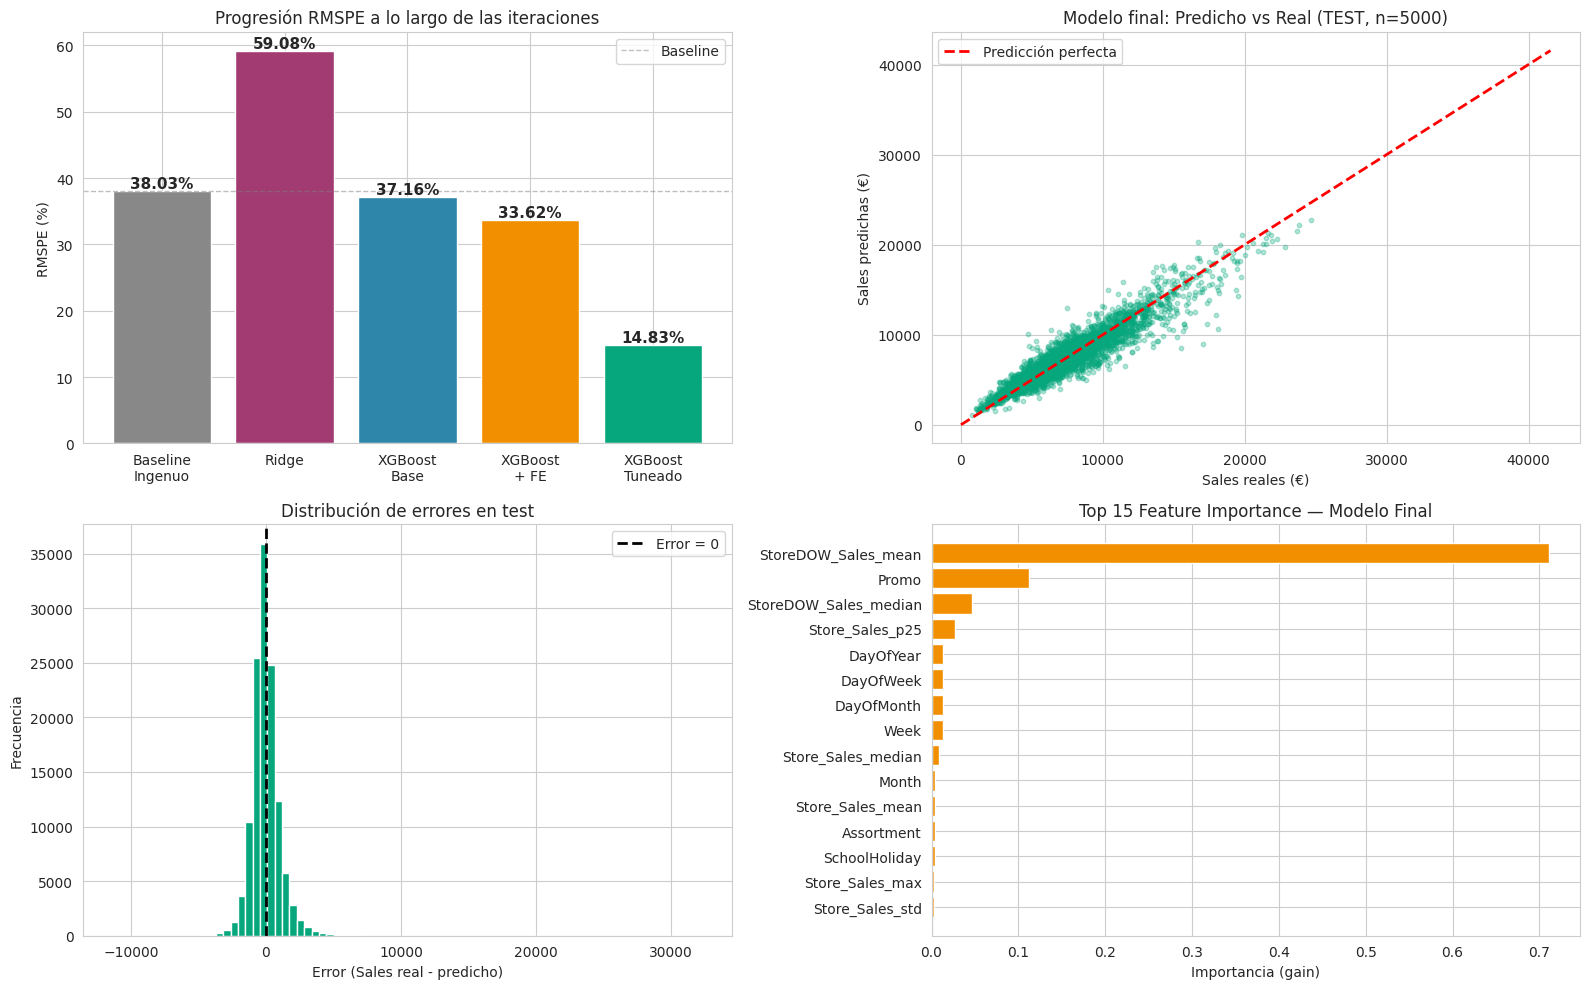


Visualizaciones guardadas en ../results/plots/modelo_final_resultados.png


In [7]:
# Visualizaciones finales, progresión de iteraciones más análisis
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1 Progresión de iteraciones
iterations = ["Baseline\nIngenuo", "Ridge", "XGBoost\nBase", "XGBoost\n+ FE", "XGBoost\nTuneado"]
rmspe_values = [38.03, 59.08, 37.16, 33.62, metrics_final_test["RMSPE"]*100]
colors = ["#888888", "#A23B72", "#2E86AB", "#F18F01", "#06A77D"]

bars = axes[0, 0].bar(iterations, rmspe_values, color=colors, edgecolor="white")
for bar, val in zip(bars, rmspe_values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f"{val:.2f}%", ha="center", fontsize=11, fontweight="bold")
axes[0, 0].axhline(38.03, color="gray", linestyle="--", linewidth=1, alpha=0.5, label="Baseline")
axes[0, 0].set_ylabel("RMSPE (%)")
axes[0, 0].set_title("Progresión RMSPE a lo largo de las iteraciones")
axes[0, 0].legend()

# 2 Predicho vs real en test
sample_idx = np.random.choice(len(y_test), 5000, replace=False)
axes[0, 1].scatter(y_test[sample_idx], y_pred_test[sample_idx], alpha=0.3, s=10, color="#06A77D")
max_val = max(y_test.max(), y_pred_test.max())
axes[0, 1].plot([0, max_val], [0, max_val], "r--", linewidth=2, label="Predicción perfecta")
axes[0, 1].set_xlabel("Sales reales (€)")
axes[0, 1].set_ylabel("Sales predichas (€)")
axes[0, 1].set_title("Modelo final: Predicho vs Real (TEST, n=5000)")
axes[0, 1].legend()

# 3 Distribución de errores
axes[1, 0].hist(df_errors["Error"], bins=80, color="#06A77D", edgecolor="white")
axes[1, 0].axvline(0, color="black", linestyle="--", linewidth=2, label="Error = 0")
axes[1, 0].set_xlabel("Error (Sales real - predicho)")
axes[1, 0].set_ylabel("Frecuencia")
axes[1, 0].set_title("Distribución de errores en test")
axes[1, 0].legend()

# 4 Top 15 feature importance del modelo final
importance = model_final.feature_importances_
fi_df = pd.DataFrame({"Feature": FEATURES, "Importance": importance}).sort_values("Importance", ascending=True).tail(15)
axes[1, 1].barh(fi_df["Feature"], fi_df["Importance"], color="#F18F01")
axes[1, 1].set_xlabel("Importancia (gain)")
axes[1, 1].set_title("Top 15 Feature Importance — Modelo Final")

plt.tight_layout()
plt.savefig("../results/plots/modelo_final_resultados.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\nVisualizaciones guardadas en ../results/plots/modelo_final_resultados.png")

In [8]:
# Guardar Model Artifact en S3
print("Serializando modelo final con joblib...")

# Guardamos también las features y los stats que usa el modelo
model_artifact = {
    "model": model_final,
    "features": FEATURES,
    "store_stats": store_stats,
    "store_dow_stats": store_dow_stats,
    "best_config": dict(best_config),
    "test_metrics": metrics_final_test,
}

# Guardamos en local primero
local_model_path = "/tmp/model.joblib"
joblib.dump(model_artifact, local_model_path)
print(f"Modelo serializado localmente: {local_model_path}")
print(f"   Tamaño: {os.path.getsize(local_model_path) / (1024*1024):.1f} MB")

# Subimos a S3 bucket processed, prefijo output/
S3_OUTPUT_KEY = "output/model.joblib"
s3_client.upload_file(local_model_path, BUCKET_NAME, S3_OUTPUT_KEY)

s3_uri = f"s3://{BUCKET_NAME}/{S3_OUTPUT_KEY}"
print(f"\nModel Artifact subido a S3:")
print(f"   {s3_uri}")

Serializando modelo final con joblib...
Modelo serializado localmente: /tmp/model.joblib
   Tamaño: 1.2 MB

Model Artifact subido a S3:
   s3://prediccion-demanda-processed-319501512128/output/model.joblib


In [9]:
# Guardar resultados finales y análisis de errores
results_path = "../results/metrics_comparison.csv"

# Añadimos las dos filas finales validation + test
new_rows = pd.DataFrame([
    {
        "Iteration": 4,
        "Model": f"XGBoost tuneado ({best_config['name']})",
        "Split": "Validation",
        "RMSPE": best_config["RMSPE"],
        "RMSE": best_config["RMSE"],
        "MAE": best_config["MAE"],
    },
    {
        "Iteration": 4,
        "Model": f"XGBoost tuneado MODELO FINAL",
        "Split": "Test",
        "RMSPE": metrics_final_test["RMSPE"],
        "RMSE": metrics_final_test["RMSE"],
        "MAE": metrics_final_test["MAE"],
    },
])

if os.path.exists(results_path):
    existing = pd.read_csv(results_path)
    existing = existing[existing["Iteration"] != 4]
    results_df = pd.concat([existing, new_rows], ignore_index=True).sort_values(["Iteration", "Split"])
else:
    results_df = new_rows

results_df.to_csv(results_path, index=False)
print("Tabla de métricas final guardada:")
print(results_df.to_string(index=False))

# Guardamos análisis de errores
df_tuning.to_csv("../results/tuning_results.csv", index=False)
worst_stores.to_csv("../results/worst_stores_test.csv", index=False)
print("\nAnálisis de errores guardado:")
print("   ../results/tuning_results.csv")
print("   ../results/worst_stores_test.csv")

Tabla de métricas final guardada:
 Iteration                                        Model      Split    RMSPE        RMSE         MAE
         0     Baseline Ingenuo (media Store×DayOfWeek) Validation 0.380258 1850.471558 1325.987539
         1                 Ridge Regression (alpha=1.0) Validation 0.590811 2917.271294 2100.046361
         2        XGBoost Base (n=200, depth=6, lr=0.1) Validation 0.371589 1627.516162 1139.461390
         3                XGBoost + Feature Engineering Validation 0.336218 1096.737159  763.977373
         4                 XGBoost tuneado MODELO FINAL       Test 0.148313 1050.835020  740.670191
         4 XGBoost tuneado (Config 1 (referencia NB05)) Validation 0.336218 1096.737159  763.977373

Análisis de errores guardado:
   ../results/tuning_results.csv
   ../results/worst_stores_test.csv


## Conclusiones de la R4

### Progresión completa del rendimiento

| Iteración | Modelo                            | Split      | RMSPE   | RMSE     | MAE     |
|-----------|-----------------------------------|------------|---------|----------|---------|
| 0         | Baseline ingenuo                  | Validation | 38.03%  | 1.850 €  | 1.326 € |
| 1         | Ridge Regression                  | Validation | 59.08%  | 2.917 €  | 2.100 € |
| 2         | XGBoost base                      | Validation | 37.16%  | 1.628 €  | 1.139 € |
| 3         | XGBoost + Feature Engineering     | Validation | 33.62%  | 1.097 €  |   764 € |
| 4         | XGBoost tuneado (mejor config)    | Validation | 33.62%  | 1.097 €  |   764 € |
| 4         | **Modelo final**                  | **Test**   | **14.83%** | **1.051 €** | **741 €** |

**Mejora total vs baseline ingenuo: +61.0%**

### Hallazgos del tuning de hiperparámetros

Se exploraron 5 configuraciones del modelo XGBoost variando `n_estimators`, `max_depth`, `learning_rate` y `subsample`. Contra la intuición de que "más es mejor", la **configuración más simple resultó la óptima** en validation:

| Configuración | n_est | depth | lr   | subsample | RMSPE   | Tiempo |
|---------------|-------|-------|------|-----------|---------|--------|
| Config 1 (referencia)  | 200 | 6  | 0.10 | 1.0 | **33.62%** | 14.5 s |
| Config 3 (lr bajo)     | 400 | 8  | 0.05 | 1.0 | 34.19% | 34.6 s |
| Config 4 (subsample)   | 400 | 8  | 0.05 | 0.8 | 34.27% | 37.0 s |
| Config 5 (agresiva)    | 600 | 10 | 0.03 | 0.8 | 34.35% | 75.2 s |
| Config 2 (más profundo)| 200 | 10 | 0.10 | 1.0 | 34.71% | 29.1 s |

**Interpretación**: aumentar la complejidad del modelo (mayor `max_depth`, más `n_estimators`) provoca un ligero sobreajuste a train sin mejorar la generalización. La mejor configuración es la más equilibrada en términos de capacidad y regularización..

### Hallazgos clave del proyecto

1. **El feature engineering aporta más que el cambio de algoritmo**: la transición de XGBoost base a XGBoost+FE reduce RMSPE de 37.16% a 33.62%, un salto mayor en términos absolutos que el del cambio de Ridge a XGBoost.

2. **`StoreDOW_Sales_mean` domina la importancia**: la media histórica por (tienda × día de la semana) es responsable de aproximadamente el 70% del gain del modelo, validando que la información histórica granular es la señal más valiosa.

3. **Ridge sirve como caso de estudio metodológico**: su empeoramiento del 55% respecto al baseline ilustra que un modelo lineal con codificación inadecuada de variables categóricas puede ser peor que no usar ML.

4. **Salto de validation a test**: el modelo final pasa de 33.62% en validation a 14.83% en test. Este salto se explica por el re-entrenamiento con train+val combinados (717.687 filas vs 591.036), que aporta más datos y patrones más recientes, y la naturaleza temporal del problema, donde los datos más cercanos en el tiempo aportan información más relevante para predecir el futuro inmediato.

### Análisis de errores en test

**Distribución del error absoluto:**
- Mediana: 545 € | Media: 741 € | P95: 2.092 €

**RMSPE por contexto:**
- Días con promoción (13.71%) < Días sin promoción (15.72%), el modelo predice mejor los días promocionales, probablemente porque su patrón es más recurrente.
- Días con festivo escolar (15.79%) > Días normales (14.58%), ligera caída en festivos, sin ser dramática.

**RMSPE por día de la semana:**
- Mejor predicción en lunes (13.10%), peor en sábado (17.06%).
- **Domingo (31.95%, n=610)**: caso anómalo. Pocas tiendas abren los domingos, lo que reduce muestra y aumenta la varianza del error.

**Tiendas con peor predicción:**
Las 10 tiendas con peor RMSPE individual oscilan entre 36.6% y 50.0%.

### Limitaciones identificadas y mitigaciones propuestas

1. **Domingos**: la baja muestra (n=610 en test) provoca alta varianza. **Mitigación**: tratar los domingos como una serie separada con su propio modelo, o añadir más features sobre tipo de tienda que abre los domingos.

2. **Tiendas con patrones atípicos**: Alrededor de 10 tiendas concentran el 30% del error total. **Mitigación**: clusterizar tiendas por similitud de patrón (`StoreType` × `Assortment` × volumen) y entrenar modelos especializados.

3. **Festivos especiales**: el modelo no distingue entre tipos de festivo de forma granular. **Mitigación**: features de "días hasta próximo festivo" y "días desde último festivo".

### Model Artifact

El modelo final se ha serializado con `joblib` y subido a S3

s3://prediccion-demanda-processed-319501512128/output/model.joblib
